In [2]:
pip install prophet

In [1]:
import pandas as pd
from prophet import Prophet

In [9]:
import yfinance as yf

df = yf.download("^NSEI", start='2010-01-01', end ='2026-01-01')
df.columns = df.columns.get_level_values(0)
df.reset_index(inplace=True)
print(df.head())
print(df.shape)

/tmp/ipython-input-3095/4222805030.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^NSEI", start='2010-01-01', end ='2026-01-01')
[*********************100%***********************]  1 of 1 completed

Price       Date        Close         High          Low         Open  Volume
0     2010-01-04  5232.200195  5238.450195  5167.100098  5200.899902       0
1     2010-01-05  5277.899902  5288.350098  5242.399902  5277.149902       0
2     2010-01-06  5281.799805  5310.850098  5260.049805  5278.149902       0
3     2010-01-07  5263.100098  5302.549805  5244.750000  5281.799805       0
4     2010-01-08  5244.750000  5276.750000  5234.700195  5264.250000       0
(3929, 6)


In [10]:
df.to_csv('nifty50.csv', index=False)

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

In [12]:
df = pd.read_csv("nifty50.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Shape:", df.shape)
print("\nDate Range:", df['Date'].min(), "→", df['Date'].max())
print("\nBasic Stats:\n", df['Close'].describe())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (3929, 6)

Date Range: 2010-01-04 00:00:00 → 2025-12-31 00:00:00

Basic Stats:
 count     3929.000000
mean     11838.522035
std       6230.830736
min       4544.200195
25%       6215.149902
50%      10113.700195
75%      16983.550781
max      26216.050781
Name: Close, dtype: float64

Missing Values:
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


Full Price History (Trend overview)

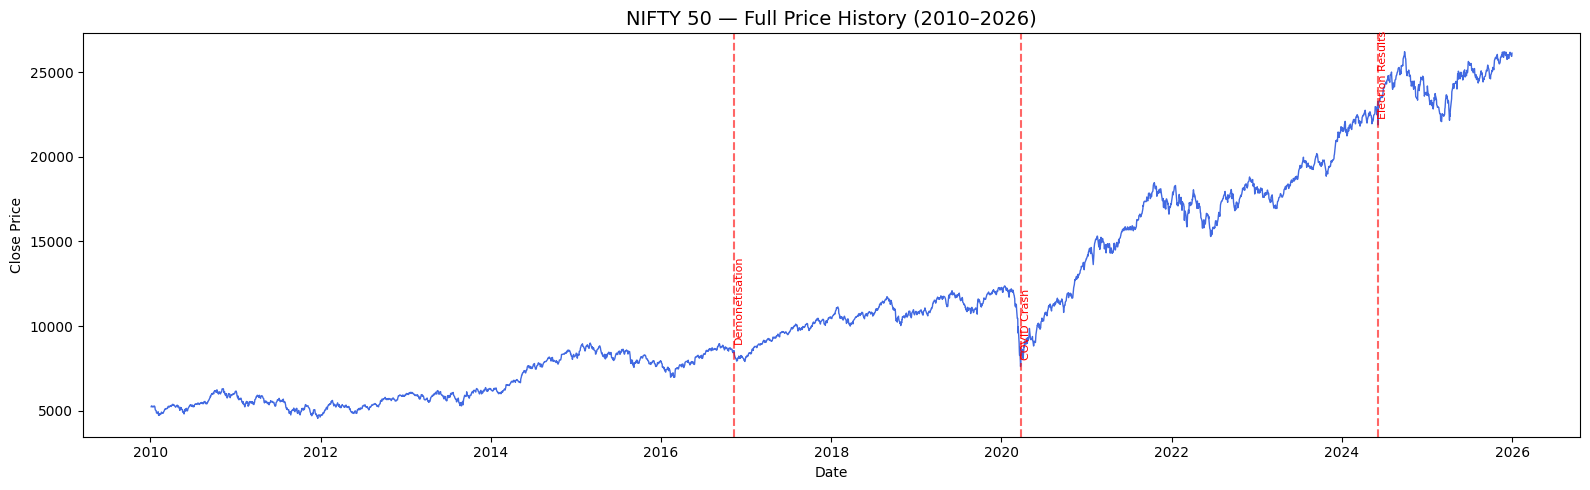

In [13]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['Date'], df['Close'], color='royalblue', linewidth=1)
ax.set_title('NIFTY 50 — Full Price History (2010–2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')
events = {
    '2016-11-08': 'Demonetisation',
    '2020-03-23': 'COVID Crash',
    '2020-11-01': 'COVID Recovery',
    '2024-06-04': 'Election Results',
}
for date, label in events.items():
    xval = pd.to_datetime(date)
    yval = df.loc[df['Date'] == xval, 'Close']
    if not yval.empty:
        ax.axvline(x=xval, color='red', linestyle='--', alpha=0.6)
        ax.text(xval, yval.values[0] + 500, label,
                rotation=90, fontsize=8, color='red')

plt.tight_layout()
plt.show()

Yearly Returns (how much NIFTY grew each year)

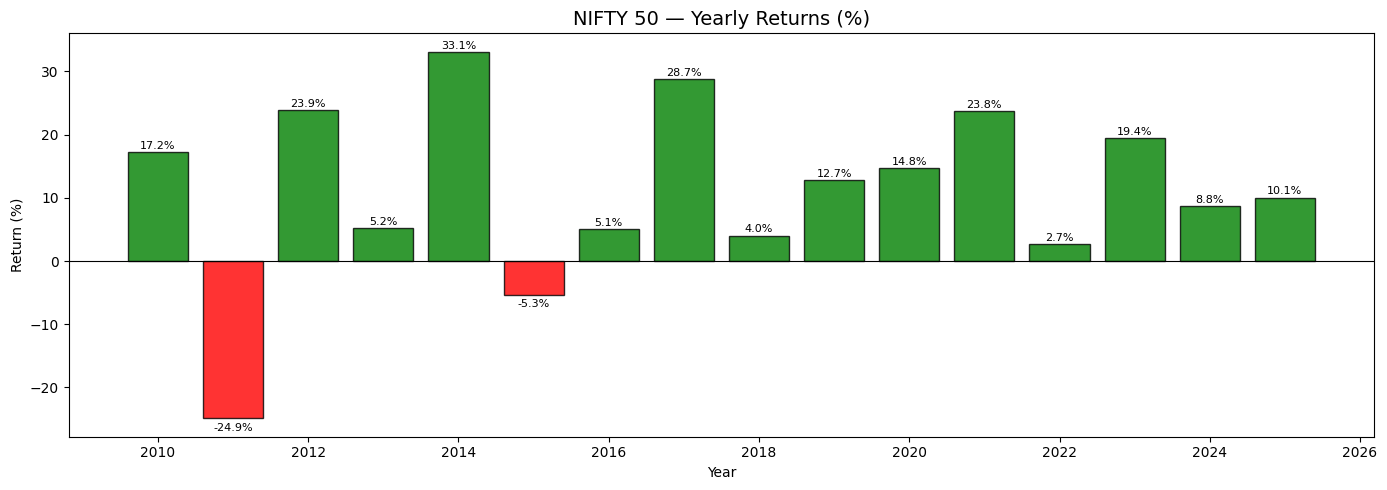

In [14]:
df['Year'] = df['Date'].dt.year

yearly = df.groupby('Year')['Close'].agg(['first', 'last'])
yearly['return_pct'] = ((yearly['last'] - yearly['first']) / yearly['first']) * 100
yearly = yearly[yearly.index < 2026]
colors = ['green' if x > 0 else 'red' for x in yearly['return_pct']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(yearly.index, yearly['return_pct'], color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('NIFTY 50 — Yearly Returns (%)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Return (%)')

for bar, val in zip(bars, yearly['return_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5 if val > 0 else bar.get_height() - 2,
            f'{val:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Monthly Seasonality (which months are bullish?)


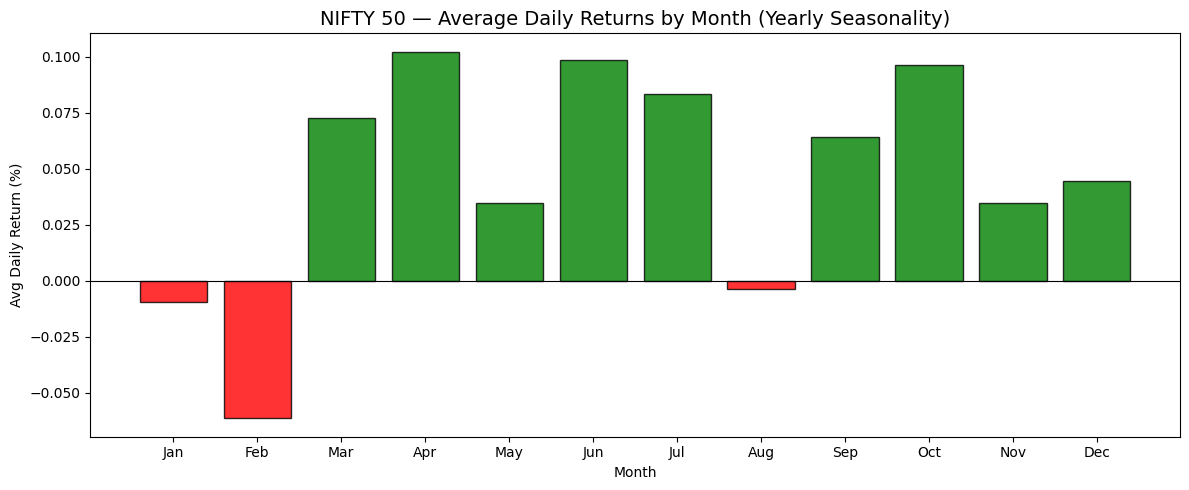

In [15]:
df['Month'] = df['Date'].dt.month
df['Daily_Return'] = df['Close'].pct_change() * 100

monthly_avg = df.groupby('Month')['Daily_Return'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

colors = ['green' if x > 0 else 'red' for x in monthly_avg]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(month_names, monthly_avg, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('NIFTY 50 — Average Daily Returns by Month (Yearly Seasonality)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Daily Return (%)')
plt.tight_layout()
plt.show()

Day of Week Seasonality (which day is bullish?)

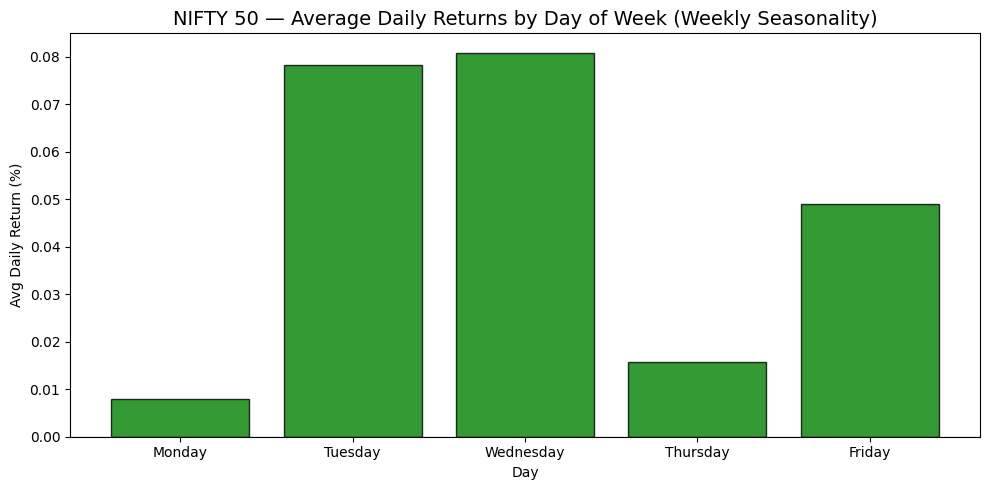

In [16]:
df['DayOfWeek'] = df['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

dow_avg = df.groupby('DayOfWeek')['Daily_Return'].mean().reindex(day_order)
colors = ['green' if x > 0 else 'red' for x in dow_avg]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(day_order, dow_avg, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('NIFTY 50 — Average Daily Returns by Day of Week (Weekly Seasonality)', fontsize=14)
ax.set_xlabel('Day')
ax.set_ylabel('Avg Daily Return (%)')
plt.tight_layout()
plt.show()

Volatility over time (rolling std dev)


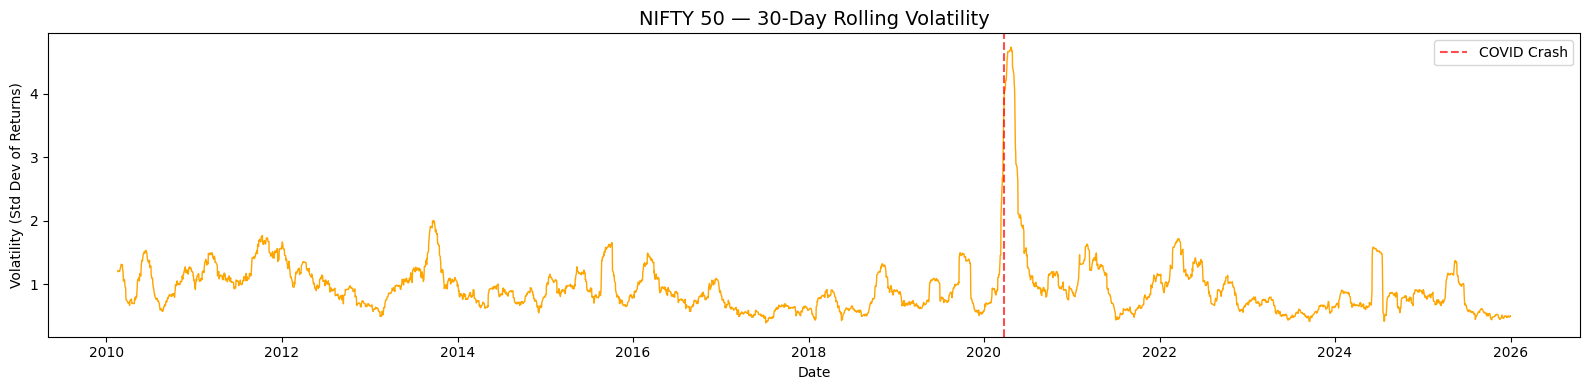

In [17]:
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['Date'], df['Volatility_30d'], color='orange', linewidth=1)
ax.set_title('NIFTY 50 — 30-Day Rolling Volatility', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Std Dev of Returns)')
ax.axvline(pd.to_datetime('2020-03-23'), color='red',
           linestyle='--', alpha=0.7, label='COVID Crash')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import holidays
import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv("nifty50.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [21]:
prophet_df = df[['Date', 'Close']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df.dropna(inplace=True)

In [22]:
print("Data Shape:", prophet_df.shape)
print("Date Range:", prophet_df['ds'].min(), "→", prophet_df['ds'].max())
print("\nFirst 5 rows:")
print(prophet_df.head())

Data Shape: (3929, 2)
Date Range: 2010-01-04 00:00:00 → 2025-12-31 00:00:00

First 5 rows:
          ds            y
0 2010-01-04  5232.200195
1 2010-01-05  5277.899902
2 2010-01-06  5281.799805
3 2010-01-07  5263.100098
4 2010-01-08  5244.750000


In [24]:
india_holidays = holidays.India(years=range(2010, 2027))

indian_holidays_df = pd.DataFrame({
    'holiday': 'indian_market_holiday',
    'ds': pd.to_datetime(list(india_holidays.keys())),
    'lower_window': -1,
    'upper_window': 1,
})

indian_holidays_df = indian_holidays_df\
    .sort_values('ds')\
    .reset_index(drop=True)

print(f"Total holidays captured: {len(indian_holidays_df)}")
print("\nSample holidays:")
print(indian_holidays_df.head(10))

Total holidays captured: 270

Sample holidays:
                 holiday         ds  lower_window  upper_window
0  indian_market_holiday 2010-01-26            -1             1
1  indian_market_holiday 2010-02-12            -1             1
2  indian_market_holiday 2010-02-27            -1             1
3  indian_market_holiday 2010-04-02            -1             1
4  indian_market_holiday 2010-04-28            -1             1
5  indian_market_holiday 2010-05-27            -1             1
6  indian_market_holiday 2010-08-15            -1             1
7  indian_market_holiday 2010-09-02            -1             1
8  indian_market_holiday 2010-09-10            -1             1
9  indian_market_holiday 2010-10-02            -1             1


In [37]:
model = Prophet(
    changepoint_prior_scale=0.15,
    n_changepoints=30,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative',
    holidays=indian_holidays_df,
    holidays_prior_scale=10,
    interval_width=0.95,
)
print("Fitting model")
model.fit(prophet_df)
print("Model fitted successfully")

Fitting model
Model fitted successfully


In [38]:
future = model.make_future_dataframe(
    periods=365,
    freq='B'
)

print(f"Future dataframe shape: {future.shape}")
print(f"Forecast goes up to: {future['ds'].max()}")
forecast = model.predict(future)
print("\nForecast sample (last 5 rows = future predictions):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Future dataframe shape: (4294, 1)
Forecast goes up to: 2027-05-26 00:00:00

Forecast sample (last 5 rows = future predictions):
             ds          yhat    yhat_lower    yhat_upper
4289 2027-05-20  30068.389525  22135.632276  38031.459221
4290 2027-05-21  30101.311470  21989.871872  37924.514215
4291 2027-05-24  30207.153911  22777.618230  38056.114047
4292 2027-05-25  30243.285560  22283.838096  38435.279748
4293 2027-05-26  30279.064324  22365.377207  38405.406294


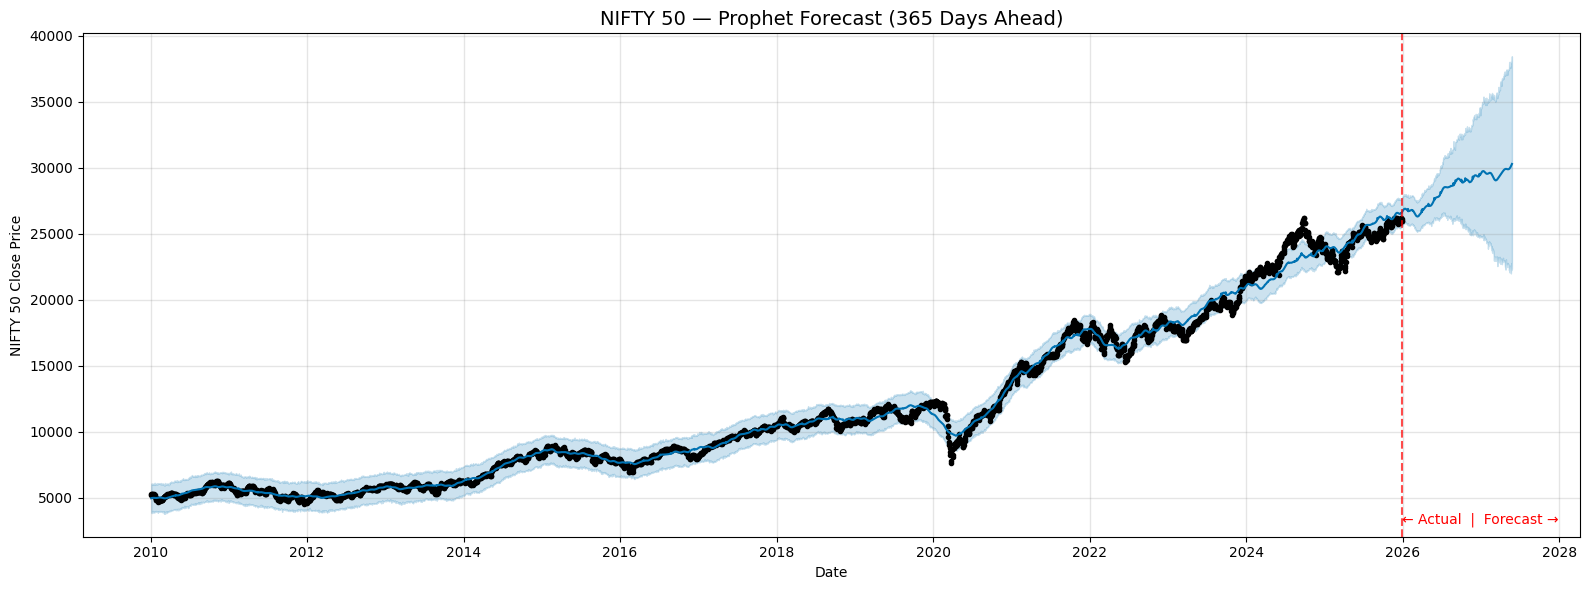

In [39]:
fig = model.plot(forecast, figsize=(16, 6))
ax = fig.gca()
ax.set_title('NIFTY 50 — Prophet Forecast (365 Days Ahead)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('NIFTY 50 Close Price')
last_date = prophet_df['ds'].max()
ax.axvline(x=last_date, color='red', linestyle='--', alpha=0.7)
ax.text(last_date, ax.get_ylim()[0] + 1000,
        '← Actual  |  Forecast →',
        color='red', fontsize=10)
plt.tight_layout()
plt.show()

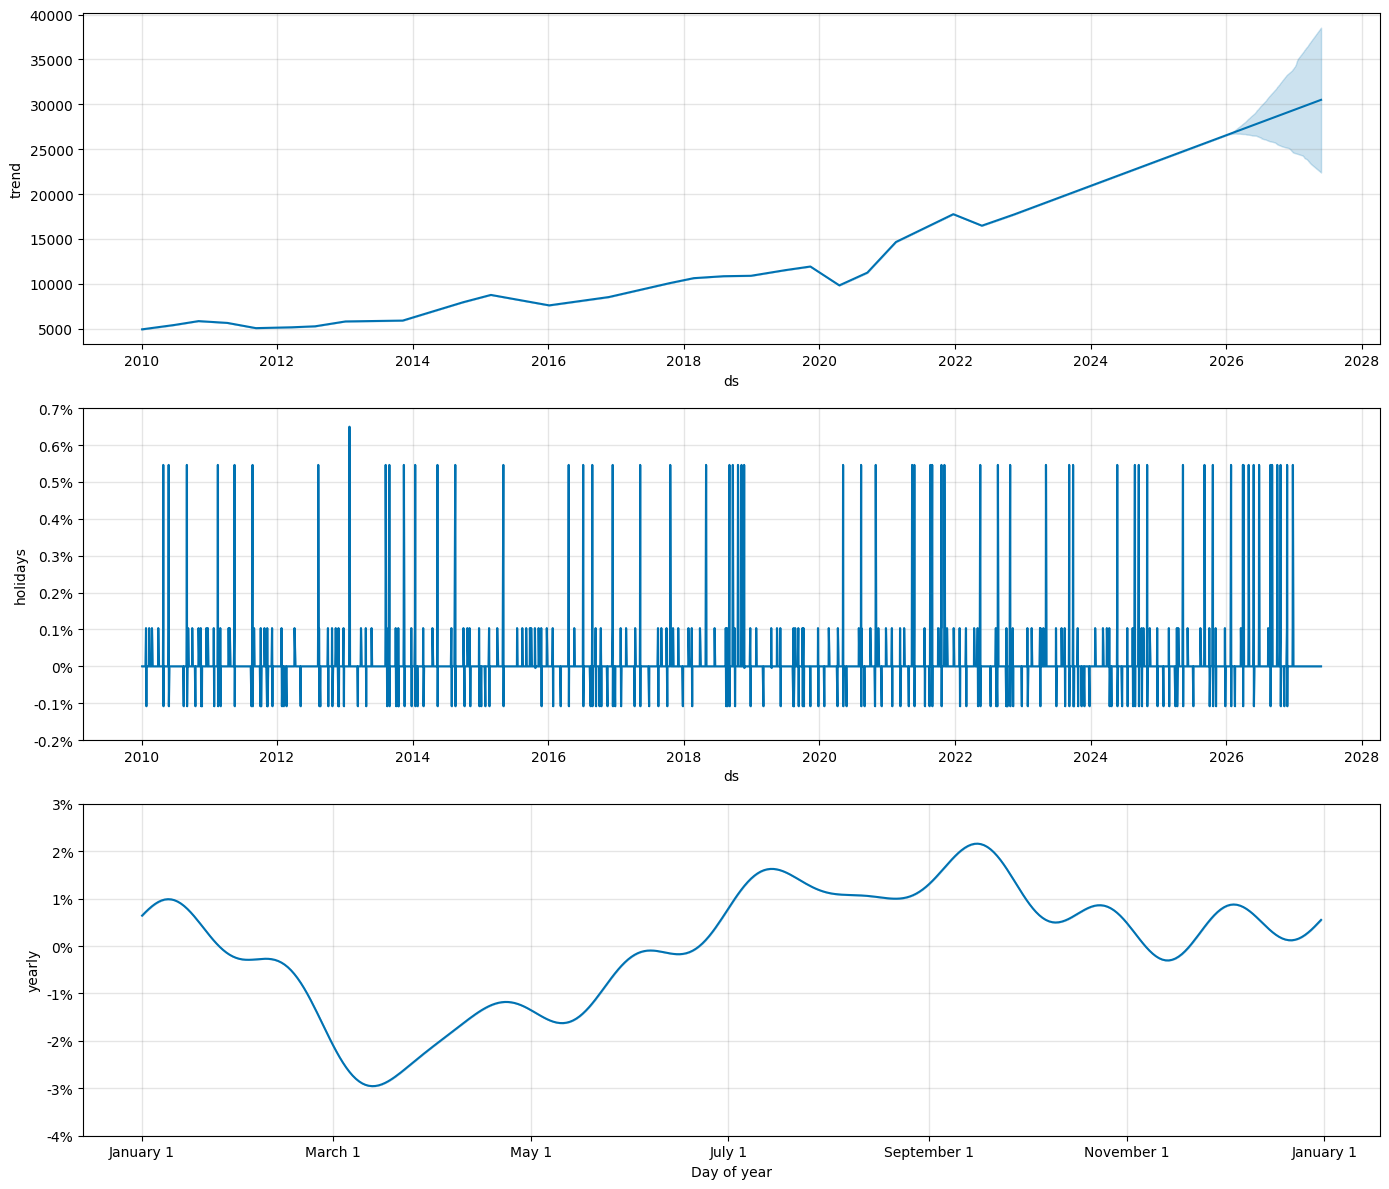

In [40]:
fig2 = model.plot_components(forecast, figsize=(14, 12))
plt.tight_layout()
plt.show()

In [41]:
print("Running cross validation (takes 1-2 mins)...")
cv_results = cross_validation(
    model,
    initial='1825 days',
    period='180 days',
    horizon='365 days',
    parallel="processes"
)
print("Cross validation done!")
print(cv_results[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].head(10))

INFO:prophet:Making 21 forecasts with cutoffs between 2015-02-22 00:00:00 and 2024-12-31 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7ccd681f31a0>


Running cross validation (takes 1-2 mins)...
Cross validation done!
          ds            y         yhat   yhat_lower   yhat_upper
0 2015-02-23  8754.950195  8726.333189  8436.516767  9006.358615
1 2015-02-24  8762.099609  8738.054319  8439.503884  8990.916387
2 2015-02-25  8767.250000  8750.146245  8470.638121  9030.160794
3 2015-02-26  8683.849609  8762.555294  8483.875007  9020.237021
4 2015-02-27  8844.599609  8775.232727  8516.797767  9070.181732
5 2015-03-02  8956.750000  8814.473039  8532.408317  9086.482255
6 2015-03-03  8996.250000  8827.851862  8536.864994  9103.114308
7 2015-03-04  8922.650391  8841.343135  8570.555127  9128.322186
8 2015-03-05  8937.750000  8854.933274  8589.532734  9149.862091
9 2015-03-09  8756.750000  8910.178031  8635.979154  9159.535117


Model Performance Metrics:
     horizon          mae         rmse      mape
0    37 days  1068.826047  1582.761199  0.070906
1    38 days  1076.098393  1585.772223  0.071546
2    39 days  1090.925032  1596.628272  0.072504
3    40 days  1105.417950  1609.318407  0.073347
4    41 days  1121.480930  1624.557052  0.074241
5    42 days  1130.819349  1634.689147  0.074896
6    43 days  1136.288374  1643.588904  0.075179
7    44 days  1139.236204  1647.964639  0.075470
8    45 days  1147.703556  1655.013549  0.076244
9    46 days  1157.353455  1664.917686  0.076921
10   47 days  1166.674760  1677.121782  0.077461
11   48 days  1186.221613  1697.678119  0.078522
12   49 days  1191.632910  1704.014087  0.078978
13   50 days  1202.116008  1716.219904  0.079912
14   51 days  1207.996057  1721.107325  0.080647
15   52 days  1214.831527  1726.553904  0.081464
16   53 days  1230.721949  1741.848280  0.082732
17   54 days  1241.171204  1755.235947  0.083203
18   55 days  1254.151145  1771.387797  0.

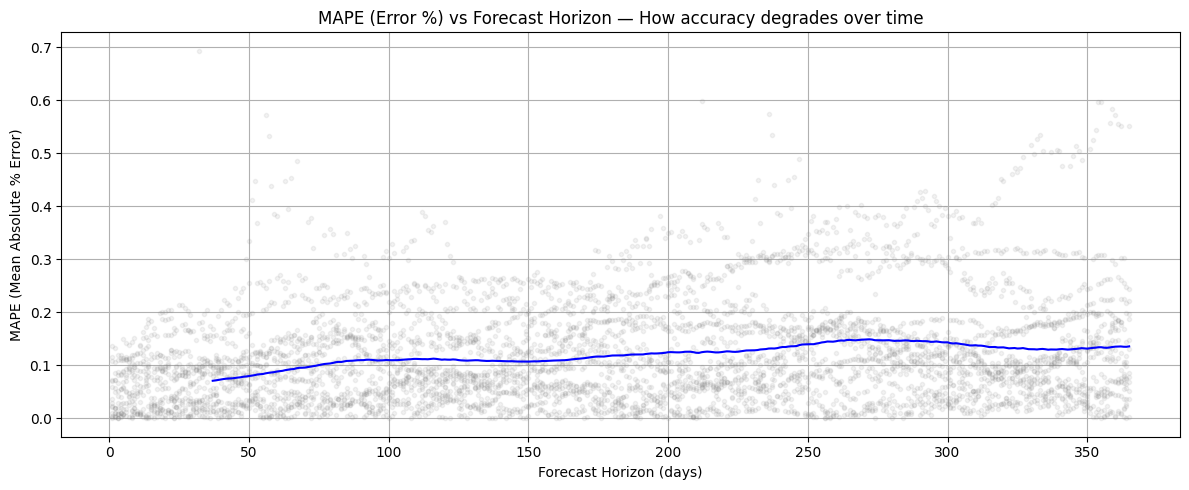

In [36]:
metrics = performance_metrics(cv_results)

print("Model Performance Metrics:")
print(metrics[['horizon', 'mae', 'rmse', 'mape']].to_string())

fig3 = plot_cross_validation_metric(cv_results, metric='mape', figsize=(12, 5))
plt.title('MAPE (Error %) vs Forecast Horizon — How accuracy degrades over time')
plt.xlabel('Forecast Horizon (days)')
plt.ylabel('MAPE (Mean Absolute % Error)')
plt.tight_layout()
plt.show()

In [45]:
from datetime import datetime

today = datetime.today()

print("Forecast start:", forecast['ds'].min().date())
print("Forecast end:  ", forecast['ds'].max().date())
print("Today:         ", today.date())

Forecast start: 2010-01-04
Forecast end:   2027-05-26
Today:          2026-02-27


In [46]:
today = pd.Timestamp('2026-02-27')
next_week = pd.bdate_range(start=today, periods=7)

next_week_forecast = forecast[
    forecast['ds'].isin(next_week)
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

next_week_forecast = next_week_forecast.round(2)
next_week_forecast.columns = ['Date', 'Predicted', 'Bear Case', 'Bull Case']
next_week_forecast['Day'] = next_week_forecast['Date'].dt.day_name()
next_week_forecast = next_week_forecast[
    ['Date', 'Day', 'Predicted', 'Bear Case', 'Bull Case']
].reset_index(drop=True)

print("NIFTY 50 — Next 7 Trading Days")
print("=" * 65)
print(next_week_forecast.to_string(index=False))

NIFTY 50 — Next 7 Trading Days
      Date       Day  Predicted  Bear Case  Bull Case
2026-02-27    Friday   26514.30   25489.48   27546.16
2026-03-02    Monday   26427.87   25273.52   27546.90
2026-03-03   Tuesday   26402.24   25277.92   27558.29
2026-03-04 Wednesday   26378.86   25278.19   27480.60
2026-03-05  Thursday   26358.06   25215.70   27428.96
2026-03-06    Friday   26340.13   25259.52   27545.93
2026-03-09    Monday   26305.37   25142.33   27350.56


In [47]:
df_fresh = yf.download("^NSEI",
                        start='2010-01-01',
                        end='2026-02-27')
df_fresh.columns = df_fresh.columns.get_level_values(0)
df_fresh.reset_index(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [48]:
prophet_df_fresh = df_fresh[['Date', 'Close']].copy()
prophet_df_fresh.columns = ['ds', 'y']
prophet_df_fresh.dropna(inplace=True)

In [49]:
model_fresh = Prophet(
    changepoint_prior_scale=0.15,
    n_changepoints=30,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative',
    holidays=indian_holidays_df,
    holidays_prior_scale=10,
    interval_width=0.95,
)

In [50]:
model_fresh.fit(prophet_df_fresh)

In [51]:
future_fresh = model_fresh.make_future_dataframe(periods=7, freq='B')
forecast_fresh = model_fresh.predict(future_fresh)

In [52]:
next_7 = forecast_fresh.tail(7)[
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].round(2)
next_7.columns = ['Date', 'Predicted', 'Bear Case', 'Bull Case']
next_7['Day'] = pd.to_datetime(next_7['Date']).dt.day_name()
next_7 = next_7[['Date', 'Day', 'Predicted', 'Bear Case', 'Bull Case']]

print("NIFTY 50 — Next 7 Days (Fresh Model)")
print("=" * 65)
print(next_7.to_string(index=False))

NIFTY 50 — Next 7 Days (Fresh Model)
      Date       Day  Predicted  Bear Case  Bull Case
2026-02-27    Friday   26184.61   25192.11   27225.97
2026-03-02    Monday   26121.62   25146.69   27206.04
2026-03-03   Tuesday   26103.90   25072.37   27177.37
2026-03-04 Wednesday   26088.34   25171.11   27154.67
2026-03-05  Thursday   26075.15   25060.28   27166.85
2026-03-06    Friday   26064.51   25018.58   27111.32
2026-03-09    Monday   26048.86   25032.49   27120.88


In [53]:
specific_dates = pd.to_datetime(['2026-02-25', '2026-02-26', '2026-02-27'])

In [54]:
specific_forecast = forecast_fresh[
    forecast_fresh['ds'].isin(specific_dates)
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

In [55]:
specific_forecast = specific_forecast.round(2)
specific_forecast.columns = ['Date', 'Predicted', 'Bear Case', 'Bull Case']
specific_forecast['Day'] = specific_forecast['Date'].dt.day_name()
specific_forecast = specific_forecast[
    ['Date', 'Day', 'Predicted', 'Bear Case', 'Bull Case']
].reset_index(drop=True)


In [57]:
print("NIFTY 50 — Feb 25, 26, 27 Predictions")
print("=" * 65)
print(specific_forecast.to_string(index=False))

NIFTY 50 — Feb 25, 26, 27 Predictions
      Date       Day  Predicted  Bear Case  Bull Case
2026-02-25 Wednesday   26231.11   25221.52   27333.51
2026-02-26  Thursday   26207.68   25179.22   27276.66
2026-02-27    Friday   26184.61   25192.11   27225.97


In [58]:
df_latest = yf.download("^NSEI",
                         start='2010-01-01',
                         end='2026-02-27')

[*********************100%***********************]  1 of 1 completed


In [59]:
df_latest.columns = df_latest.columns.get_level_values(0)
df_latest.reset_index(inplace=True)

In [60]:
prophet_latest = df_latest[['Date', 'Close']].copy()
prophet_latest.columns = ['ds', 'y']
prophet_latest.dropna(inplace=True)

In [61]:
print(f"Last data point: {prophet_latest['ds'].iloc[-1].date()}")
print(f"Last close:      {prophet_latest['y'].iloc[-1]:.2f}")

Last data point: 2026-02-26
Last close:      25496.55


In [62]:
model_latest = Prophet(
    changepoint_prior_scale=0.15,
    n_changepoints=30,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative',
    holidays=indian_holidays_df,
    holidays_prior_scale=10,
    interval_width=0.95,
)

In [63]:
print("Fitting model on latest data...")
model_latest.fit(prophet_latest)

Fitting model on latest data...


In [64]:
future_latest = model_latest.make_future_dataframe(periods=30, freq='B')
forecast_latest = model_latest.predict(future_latest)
print("Forecast generated!")

Forecast generated!


In [65]:
specific_dates = pd.to_datetime(['2026-02-25', '2026-02-26', '2026-02-27'])

In [66]:
specific_forecast = forecast_latest[
    forecast_latest['ds'].isin(specific_dates)
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

In [67]:
specific_forecast = specific_forecast.round(2)
specific_forecast.columns = ['Date', 'Predicted', 'Bear Case', 'Bull Case']
specific_forecast['Day'] = specific_forecast['Date'].dt.day_name()
specific_forecast = specific_forecast[
    ['Date', 'Day', 'Predicted', 'Bear Case', 'Bull Case']
].reset_index(drop=True)

print("NIFTY 50 — Feb 25, 26, 27")
print("=" * 65)
print(specific_forecast.to_string(index=False))

NIFTY 50 — Feb 25, 26, 27
      Date       Day  Predicted  Bear Case  Bull Case
2026-02-25 Wednesday   26231.11   25098.82   27293.31
2026-02-26  Thursday   26207.68   25170.18   27211.76
2026-02-27    Friday   26184.61   25183.89   27258.35


In [68]:
import holidays
import pandas as pd
from prophet import Prophet


print(f"Training data last point: {prophet_latest['ds'].iloc[-1].date()}")
print(f"Last close: {prophet_latest['y'].iloc[-1]:.2f}")

india_hols = holidays.India(years=range(2010, 2027))
indian_holidays_df = pd.DataFrame({
    'holiday': 'indian_market_holiday',
    'ds': pd.to_datetime(list(india_hols.keys())),
    'lower_window': -1,
    'upper_window': 1,
}).sort_values('ds').reset_index(drop=True)

model_v2 = Prophet(
    changepoint_prior_scale=0.15,
    n_changepoints=30,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative',
    holidays=indian_holidays_df,
    holidays_prior_scale=10,
    interval_width=0.95,
)

print("\nFitting fresh model...")
model_v2.fit(prophet_latest)
print(f"Model fitted! Training ends at: {model_v2.history['ds'].iloc[-1].date()}")

future_v2    = model_v2.make_future_dataframe(periods=30, freq='B')
forecast_v2  = model_v2.predict(future_v2)
print(f"Forecast generated! Goes up to: {forecast_v2['ds'].max().date()}")

specific_dates = pd.to_datetime(['2026-02-25', '2026-02-26', '2026-02-27'])

result = forecast_v2[
    forecast_v2['ds'].isin(specific_dates)
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

result = result.round(2)
result.columns = ['Date', 'Predicted', 'Bear Case', 'Bull Case']
result['Day'] = result['Date'].dt.day_name()
result = result[['Date', 'Day', 'Predicted', 'Bear Case', 'Bull Case']]
result = result.reset_index(drop=True)

print("\nNIFTY 50 — Feb 25, 26, 27 (V2 Fresh Model)")
print("=" * 65)
print(result.to_string(index=False))
actuals = {
    '2026-02-25': 25483.00,
    '2026-02-26': 25496.55,
    '2026-02-27': None
}

print("\nAccuracy Check")
print("=" * 75)
for _, row in result.iterrows():
    date_str = str(row['Date'].date())
    actual   = actuals.get(date_str)

    if actual:
        error_pts = actual - row['Predicted']
        error_pct = (error_pts / actual) * 100
        in_band   = '✅' if row['Bear Case'] <= actual <= row['Bull Case'] else '❌'
        arrow     = "📈" if error_pts > 0 else "📉"
        print(f"{arrow} {row['Day']:10} {date_str} | "
              f"Predicted: {row['Predicted']:>10,.2f} | "
              f"Actual: {actual:>10,.2f} | "
              f"Error: {error_pts:>+8.2f} ({error_pct:>+.2f}%) | "
              f"In Band: {in_band}")
    else:
        print(f"⏳ {row['Day']:10} {date_str} | "
              f"Predicted: {row['Predicted']:>10,.2f} | "
              f"Actual: Not available yet")

Training data last point: 2026-02-26
Last close: 25496.55

Fitting fresh model...
Model fitted! Training ends at: 2026-02-26
Forecast generated! Goes up to: 2026-04-09

NIFTY 50 — Feb 25, 26, 27 (V2 Fresh Model)
      Date       Day  Predicted  Bear Case  Bull Case
2026-02-25 Wednesday   26231.11   25205.02   27265.31
2026-02-26  Thursday   26207.68   25232.26   27261.58
2026-02-27    Friday   26184.61   25186.55   27269.87

Accuracy Check
📉 Wednesday  2026-02-25 | Predicted:  26,231.11 | Actual:  25,483.00 | Error:  -748.11 (-2.94%) | In Band: ✅
📉 Thursday   2026-02-26 | Predicted:  26,207.68 | Actual:  25,496.55 | Error:  -711.13 (-2.79%) | In Band: ✅
⏳ Friday     2026-02-27 | Predicted:  26,184.61 | Actual: Not available yet
